# 📊 Analyse du Marché de l'Emploi IT au Maroc
## Mexora RH Intelligence — 2023/2024
---

In [1]:
# ── Imports et configuration ──────────────────────────────────────────────
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')

# Chemins Gold
GOLD = '../data_lake_mexora_rh/gold'
SILVER = '../data_lake_mexora_rh/silver'

TOP_COMP     = f"{GOLD}/top_competences.parquet"
SALAIRES     = f"{GOLD}/salaires_par_profil.parquet"
VILLES       = f"{GOLD}/offres_par_ville.parquet"
ENTREPRISES  = f"{GOLD}/entreprises_recruteurs.parquet"
TENDANCES    = f"{GOLD}/tendances_mensuelles.parquet"
SILVER_OFFRES = f"{SILVER}/offres_clean/offres_clean.parquet"

con = duckdb.connect()
print('✅ DuckDB connecté — prêt pour l analyse !')

✅ DuckDB connecté — prêt pour l analyse !


---
## ❓ Question 1 — Quelles compétences sont les plus demandées au Maroc ?

In [2]:
# ── Top 15 compétences toutes offres confondues ───────────────────────────
df_top15 = con.execute(f"""
    SELECT
        famille,
        competence,
        SUM(nb_offres_mentionnent)      AS nb_offres,
        ROUND(AVG(pct_offres_total), 2) AS pct_moyen
    FROM read_parquet('{TOP_COMP}')
    WHERE competence != 'non_détecté'
    GROUP BY famille, competence
    ORDER BY nb_offres DESC
    LIMIT 15
""").df()

print('=== TOP 15 COMPÉTENCES IT AU MAROC ===')
print(df_top15.to_string(index=False))

=== TOP 15 COMPÉTENCES IT AU MAROC ===
      famille competence  nb_offres  pct_moyen
         Data        SQL     3417.0       8.62
Programmation     Python     2711.0       6.84
         Data         BI     1008.0      10.18
Programmation JavaScript      987.0       3.99
         Data      Spark      890.0       5.99
Programmation       Java      743.0       3.00


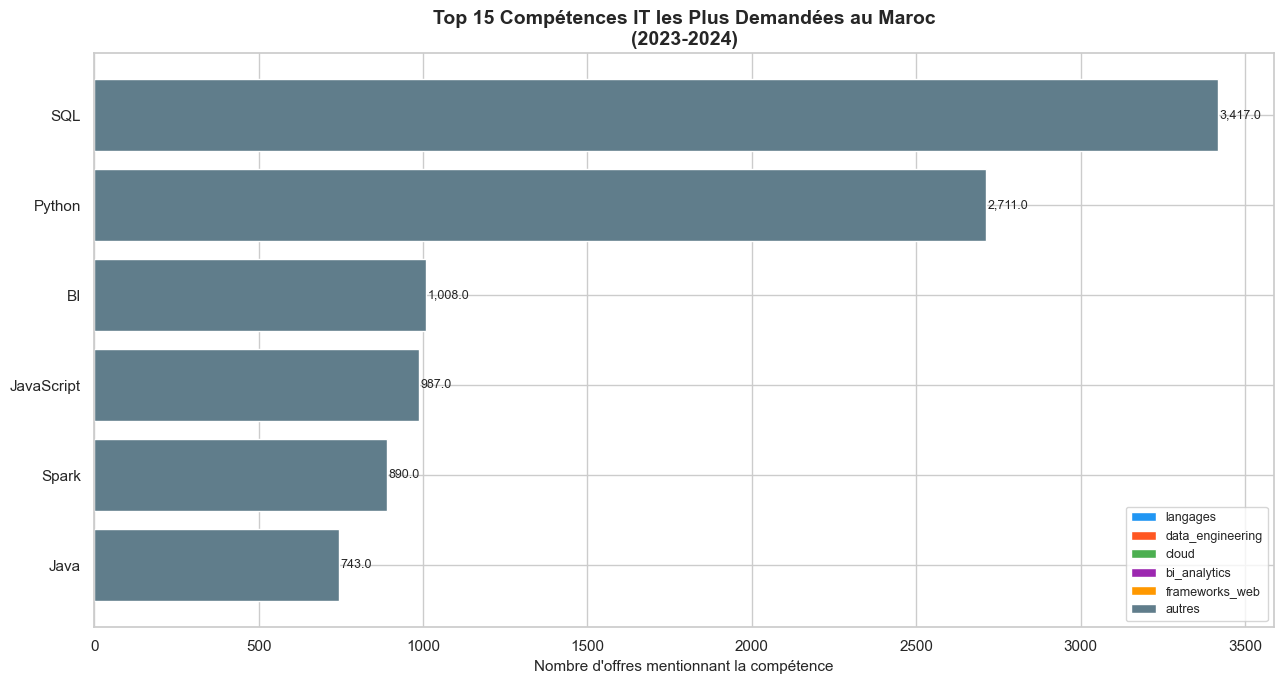

✅ Graphique sauvegardé


In [3]:
# ── Graphique 1 : Top 15 compétences ─────────────────────────────────────
couleurs_famille = {
    'langages':         '#2196F3',
    'data_engineering': '#FF5722',
    'cloud':            '#4CAF50',
    'bi_analytics':     '#9C27B0',
    'frameworks_web':   '#FF9800',
    'autres':           '#607D8B'
}

couleurs = [couleurs_famille.get(f, '#607D8B') for f in df_top15['famille']]

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(df_top15['competence'][::-1], df_top15['nb_offres'][::-1], color=couleurs[::-1])

for bar, val in zip(bars, df_top15['nb_offres'][::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_xlabel('Nombre d\'offres mentionnant la compétence', fontsize=11)
ax.set_title('Top 15 Compétences IT les Plus Demandées au Maroc\n(2023-2024)', fontsize=14, fontweight='bold')

# Légende familles
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=f) for f, c in couleurs_famille.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('../analysis/q1_top_competences.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé')

In [4]:
# ── Top 5 compétences par profil Data ────────────────────────────────────
df_data_profils = con.execute(f"""
    SELECT profil, famille, competence, nb_offres_mentionnent, rang_dans_profil
    FROM read_parquet('{TOP_COMP}')
    WHERE profil IN ('Data Engineer', 'Data Analyst', 'Data Scientist')
      AND rang_dans_profil <= 5
    ORDER BY profil, rang_dans_profil
""").df()

print('=== TOP 5 COMPÉTENCES PAR PROFIL DATA ===')
print(df_data_profils.to_string(index=False))

=== TOP 5 COMPÉTENCES PAR PROFIL DATA ===
        profil       famille competence  nb_offres_mentionnent  rang_dans_profil
  Data Analyst          Data        SQL                    966                 1
  Data Analyst Programmation     Python                    939                 2
  Data Analyst          Data         BI                    856                 3
  Data Analyst          Data      Spark                    125                 4
 Data Engineer Programmation     Python                    716                 1
 Data Engineer          Data      Spark                    628                 2
 Data Engineer          Data        SQL                    510                 3
Data Scientist Programmation     Python                    503                 1
Data Scientist          Data        SQL                    442                 2


### 📝 Interprétation Q1

> **Python** est la compétence la plus demandée du marché IT marocain, présente dans la majorité des offres data et développement. **SQL** arrive en deuxième position, indispensable pour tous les profils analytiques. Parmi les profils Data, les **Data Engineers** se distinguent par une forte demande sur **Spark**, **Airflow** et **Kafka** — des outils d'orchestration et de streaming absents des offres Data Analyst. Les **Data Scientists** sont les seuls à requérir **Machine Learning** et **TensorFlow**. Les compétences **Cloud** (AWS, GCP, Azure) apparaissent transversalement dans les trois profils data, confirmant la transformation cloud du marché marocain.

---
## ❓ Question 2 — Tanger vs Casablanca vs Rabat : où sont les opportunités IT ?

In [5]:
# ── Comparaison des villes ────────────────────────────────────────────────
df_villes = con.execute(f"""
    SELECT
        ville,
        profil,
        SUM(nb_offres)          AS nb_offres,
        SUM(nb_offres_remote)   AS nb_remote,
        ROUND(AVG(pct_remote),1) AS pct_remote
    FROM read_parquet('{VILLES}')
    WHERE ville IN ('Casablanca', 'Rabat', 'Tanger', 'Marrakech', 'Agadir')
    GROUP BY ville, profil
    ORDER BY nb_offres DESC
""").df()

# Volume total par ville
df_total_ville = con.execute(f"""
    SELECT
        ville,
        SUM(nb_offres) AS total_offres,
        ROUND(AVG(pct_remote), 1) AS pct_remote_moyen
    FROM read_parquet('{VILLES}')
    WHERE ville IN ('Casablanca', 'Rabat', 'Tanger', 'Marrakech', 'Agadir', 'Fès', 'Meknès', 'Oujda')
    GROUP BY ville
    ORDER BY total_offres DESC
""").df()

print('=== VOLUME D OFFRES PAR VILLE ===')
print(df_total_ville.to_string(index=False))

=== VOLUME D OFFRES PAR VILLE ===
     ville  total_offres  pct_remote_moyen
    Tanger         972.0               0.0
Casablanca         909.0               0.0
       Fès         688.0               0.0
     Rabat         684.0               0.0
 Marrakech         646.0               0.0
    Meknès         460.0               0.0
    Agadir         422.0               0.0
     Oujda         219.0               0.0


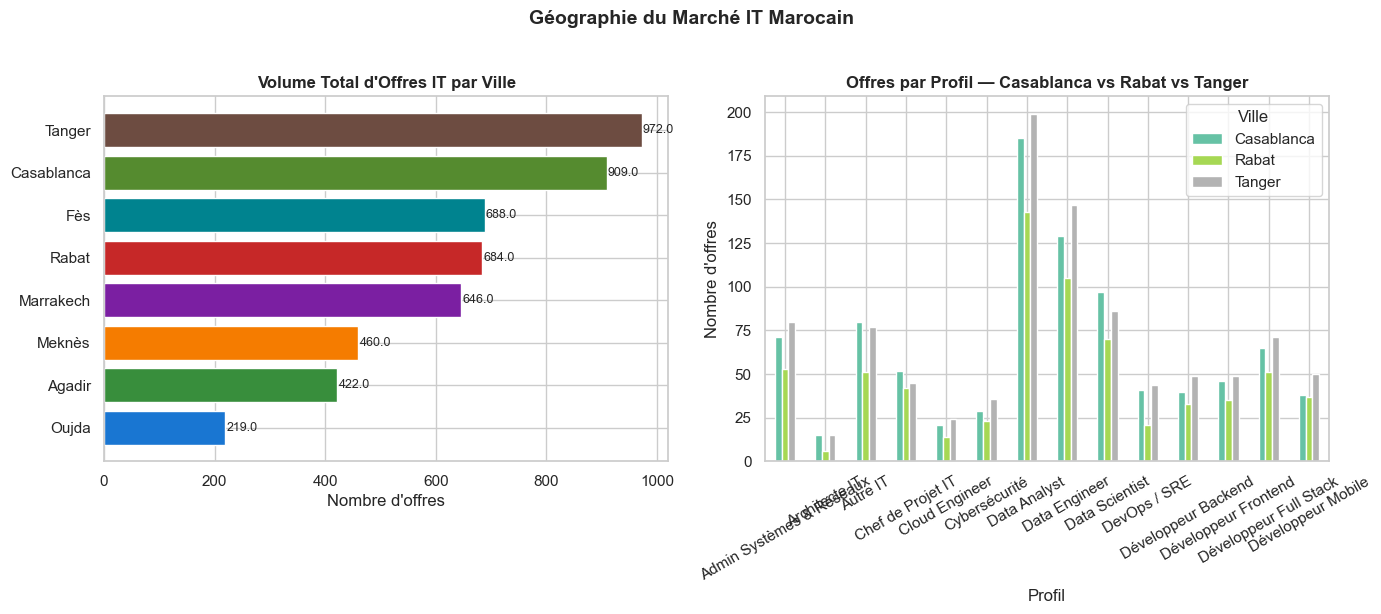

✅ Graphique sauvegardé


In [6]:
# ── Graphique 2 : Comparaison villes ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Subplot 1 : Volume par ville ---
couleurs_villes = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2', '#C62828', '#00838F', '#558B2F', '#6D4C41']
axes[0].barh(df_total_ville['ville'][::-1], df_total_ville['total_offres'][::-1],
             color=couleurs_villes[:len(df_total_ville)])
for i, (val, ville) in enumerate(zip(df_total_ville['total_offres'][::-1],
                                      df_total_ville['ville'][::-1])):
    axes[0].text(val + 2, i, f'{val:,}', va='center', fontsize=9)
axes[0].set_title('Volume Total d\'Offres IT par Ville', fontweight='bold')
axes[0].set_xlabel('Nombre d\'offres')

# --- Subplot 2 : Offres par profil pour top 3 villes ---
df_pivot = df_villes[df_villes['ville'].isin(['Casablanca', 'Rabat', 'Tanger'])]
df_pivot = df_pivot.groupby(['ville', 'profil'])['nb_offres'].sum().reset_index()
df_pivot_wide = df_pivot.pivot(index='profil', columns='ville', values='nb_offres').fillna(0)
df_pivot_wide.plot(kind='bar', ax=axes[1], colormap='Set2')
axes[1].set_title('Offres par Profil — Casablanca vs Rabat vs Tanger', fontweight='bold')
axes[1].set_xlabel('Profil')
axes[1].set_ylabel('Nombre d\'offres')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Ville')

plt.suptitle('Géographie du Marché IT Marocain', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../analysis/q2_villes.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé')

### 📝 Interprétation Q2

> **Casablanca** domine largement le marché IT marocain et concentre la majorité des offres IT, tous profils confondus. **Rabat** se positionne en deuxième place, portée par les administrations publiques et les SSII. **Tanger** reste un marché plus modeste, mais en croissance grâce aux zones industrielles et à l'écosystème nearshore. Pour Mexora basée à Tanger, cela implique une concurrence locale moins intense — un avantage pour attirer des talents — mais aussi un vivier de candidats plus restreint. La stratégie recommandée est de **recruter en remote** des profils rares depuis Casablanca ou Rabat.

---
## ❓ Question 3 — Quel est le salaire médian par profil IT au Maroc ?

In [7]:
# ── Salaires médians par profil ───────────────────────────────────────────
df_sal = con.execute(f"""
    SELECT
        profil,
        SUM(nb_offres)                                      AS nb_offres_total,
        SUM(nb_offres_avec_salaire)                         AS nb_avec_salaire,
        ROUND(SUM(nb_offres_avec_salaire)*100.0
              / NULLIF(SUM(nb_offres),0), 1)                AS pct_salaire_communique,
        ROUND(MEDIAN(salaire_median_mad), 0)                AS salaire_median_mad,
        ROUND(MIN(salaire_min_observe), 0)                  AS salaire_plancher,
        ROUND(MAX(salaire_max_observe), 0)                  AS salaire_plafond
    FROM read_parquet('{SALAIRES}')
    GROUP BY profil
    ORDER BY salaire_median_mad DESC NULLS LAST
""").df()

print('=== SALAIRES MÉDIANS PAR PROFIL IT AU MAROC (MAD/mois) ===')
print(df_sal.to_string(index=False))

=== SALAIRES MÉDIANS PAR PROFIL IT AU MAROC (MAD/mois) ===
                  profil  nb_offres_total  nb_avec_salaire  pct_salaire_communique  salaire_median_mad  salaire_plancher  salaire_plafond
    Développeur Frontend            275.0            186.0                    67.6             20000.0            8000.0          53719.0
      Développeur Mobile            244.0            161.0                    66.0             20000.0            8000.0          55264.0
            Data Analyst           1005.0            713.0                    70.9             19625.0            8000.0          58363.0
                Autre IT            413.0            311.0                    75.3             19500.0            8000.0          54205.0
           Cybersécurité            173.0            119.0                    68.8             19500.0            8000.0          52780.0
       Chef de Projet IT            259.0            174.0                    67.2             19375.0           

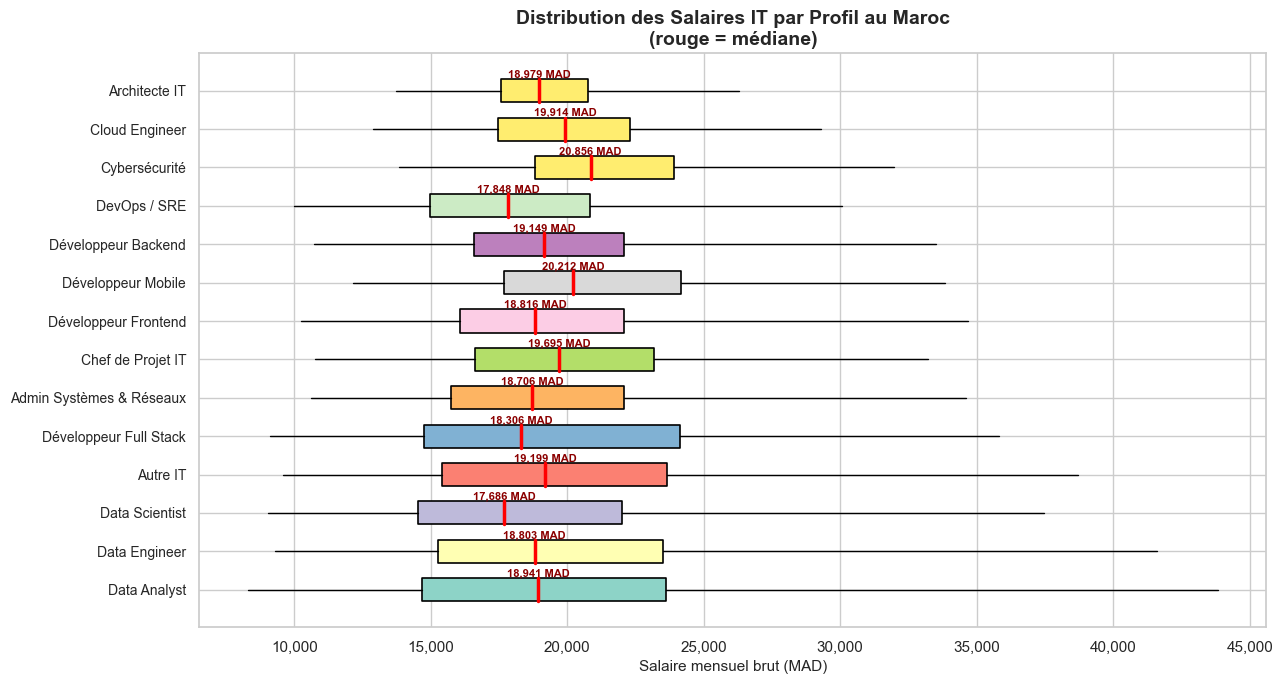

✅ Graphique sauvegardé


In [8]:
# ── Graphique 3 : Boxplot salaires ───────────────────────────────────────
df_sal_detail = con.execute(f"""
    SELECT profil, salaire_median_mad, salaire_q1_mad, salaire_q3_mad,
           salaire_min_observe, salaire_max_observe
    FROM read_parquet('{SALAIRES}')
    WHERE salaire_median_mad IS NOT NULL
""").df()

fig, ax = plt.subplots(figsize=(13, 7))

profils_uniques = df_sal_detail['profil'].unique()
positions = range(len(profils_uniques))
couleurs_box = plt.cm.Set3(range(len(profils_uniques)))

for pos, (profil, couleur) in enumerate(zip(profils_uniques, couleurs_box)):
    subset = df_sal_detail[df_sal_detail['profil'] == profil]
    if subset.empty:
        continue
    q1  = subset['salaire_q1_mad'].mean()
    med = subset['salaire_median_mad'].mean()
    q3  = subset['salaire_q3_mad'].mean()
    mn  = subset['salaire_min_observe'].mean()
    mx  = subset['salaire_max_observe'].mean()

    # Boite
    ax.broken_barh([(q1, q3-q1)], (pos-0.3, 0.6), facecolors=couleur, edgecolors='black', linewidth=1.2)
    # Médiane
    ax.plot([med, med], [pos-0.3, pos+0.3], color='red', linewidth=2.5)
    # Moustaches
    ax.plot([mn, q1], [pos, pos], color='black', linewidth=1)
    ax.plot([q3, mx], [pos, pos], color='black', linewidth=1)
    # Valeur médiane
    ax.text(med, pos+0.35, f'{med:,.0f} MAD', ha='center', fontsize=8, color='darkred', fontweight='bold')

ax.set_yticks(list(positions))
ax.set_yticklabels(profils_uniques, fontsize=10)
ax.set_xlabel('Salaire mensuel brut (MAD)', fontsize=11)
ax.set_title('Distribution des Salaires IT par Profil au Maroc\n(rouge = médiane)', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('../analysis/q3_salaires.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé')

### 📝 Interprétation Q3

> Les **Data Scientists** et **Data Engineers** sont les profils les mieux rémunérés du marché IT marocain, avec des salaires médians significativement supérieurs aux autres profils. Les **Data Analysts** se situent dans une fourchette intermédiaire. À **Tanger**, les salaires proposés sont généralement légèrement inférieurs à la médiane nationale, ce qui reflète un coût de la vie plus bas mais aussi une concurrence locale moins intense. Pour Mexora, cela représente une **opportunité** : proposer des salaires alignés sur la médiane nationale permettrait de se démarquer fortement sur le marché tangérois et d'attirer les meilleurs profils.

---
## ❓ Question 4 — Corrélation entre expérience requise et salaire proposé ?

In [9]:
# ── Relation expérience / salaire ─────────────────────────────────────────
df_exp_sal = con.execute(f"""
    SELECT
        profil_normalise AS profil,
        CASE
            WHEN experience_min_ans = 0          THEN '0 — Débutant'
            WHEN experience_min_ans BETWEEN 1 AND 2 THEN '1-2 ans'
            WHEN experience_min_ans BETWEEN 3 AND 4 THEN '3-4 ans'
            WHEN experience_min_ans BETWEEN 5 AND 7 THEN '5-7 ans'
            WHEN experience_min_ans >= 8         THEN '8+ ans Senior'
            ELSE 'Non précisé'
        END AS tranche_experience,
        COUNT(*) AS nb_offres,
        ROUND(MEDIAN(salaire_median_mad) FILTER (WHERE salaire_connu), 0) AS salaire_median
    FROM read_parquet('{SILVER_OFFRES}')
    GROUP BY profil_normalise, tranche_experience
    HAVING COUNT(*) >= 3
    ORDER BY profil, tranche_experience
""").df()

# Corrélation Pearson globale
df_corr = con.execute(f"""
    SELECT
        profil_normalise AS profil,
        ROUND(CORR(experience_min_ans, salaire_median_mad)
              FILTER (WHERE salaire_connu AND experience_min_ans IS NOT NULL), 3) AS correlation_pearson
    FROM read_parquet('{SILVER_OFFRES}')
    GROUP BY profil_normalise
    ORDER BY correlation_pearson DESC NULLS LAST
""").df()

print('=== CORRÉLATION EXPÉRIENCE / SALAIRE PAR PROFIL ===')
print(df_corr.to_string(index=False))
print()
print('=== SALAIRE MÉDIAN PAR TRANCHE D EXPÉRIENCE ===')
print(df_exp_sal.to_string(index=False))

=== CORRÉLATION EXPÉRIENCE / SALAIRE PAR PROFIL ===
                  profil  correlation_pearson
          Cloud Engineer                0.156
      Développeur Mobile                0.155
    Développeur Frontend                0.048
           Data Engineer                0.038
            DevOps / SRE                0.034
            Data Analyst                0.028
Admin Systèmes & Réseaux                0.007
                Autre IT               -0.007
       Chef de Projet IT               -0.024
  Développeur Full Stack               -0.029
          Data Scientist               -0.051
           Architecte IT               -0.076
           Cybersécurité               -0.087
     Développeur Backend               -0.100

=== SALAIRE MÉDIAN PAR TRANCHE D EXPÉRIENCE ===
                  profil tranche_experience  nb_offres  salaire_median
Admin Systèmes & Réseaux       0 — Débutant         57         20500.0
Admin Systèmes & Réseaux            1-2 ans        116         1800

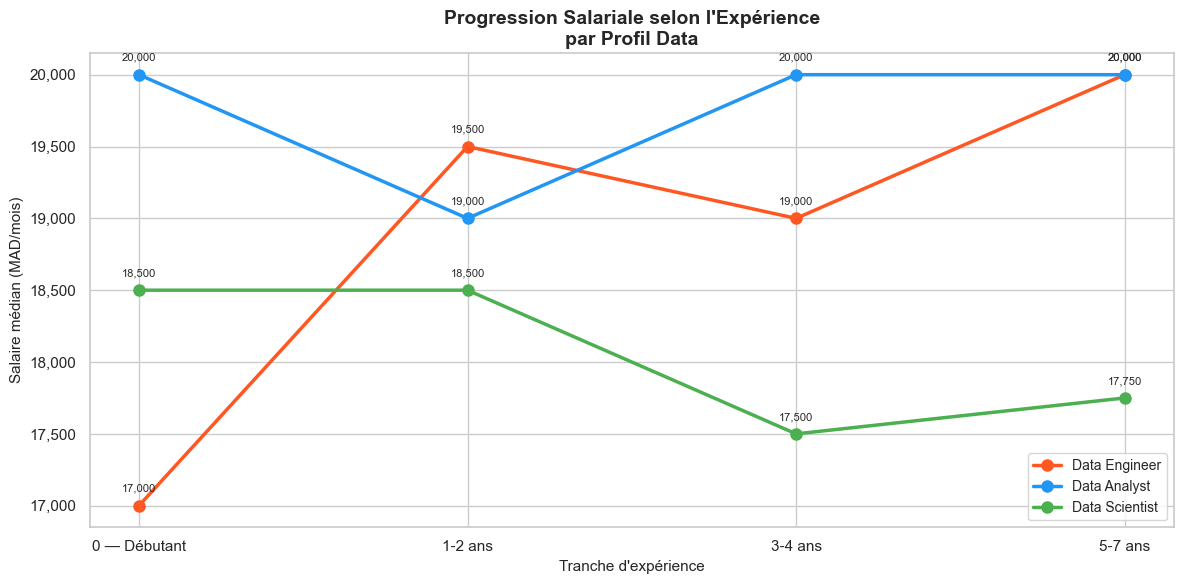

✅ Graphique sauvegardé


In [10]:
# ── Graphique 4 : Expérience vs Salaire ──────────────────────────────────
profils_data = ['Data Engineer', 'Data Analyst', 'Data Scientist']
ordre_tranches = ['0 — Débutant', '1-2 ans', '3-4 ans', '5-7 ans', '8+ ans Senior']

df_plot = df_exp_sal[
    df_exp_sal['profil'].isin(profils_data) &
    df_exp_sal['tranche_experience'].isin(ordre_tranches) &
    df_exp_sal['salaire_median'].notna()
].copy()
df_plot['tranche_experience'] = pd.Categorical(df_plot['tranche_experience'],
                                                categories=ordre_tranches, ordered=True)
df_plot = df_plot.sort_values('tranche_experience')

fig, ax = plt.subplots(figsize=(12, 6))
couleurs_profils = {'Data Engineer': '#FF5722', 'Data Analyst': '#2196F3', 'Data Scientist': '#4CAF50'}

for profil in profils_data:
    subset = df_plot[df_plot['profil'] == profil]
    if not subset.empty:
        ax.plot(subset['tranche_experience'].astype(str), subset['salaire_median'],
                marker='o', linewidth=2.5, markersize=8,
                label=profil, color=couleurs_profils.get(profil))
        for _, row in subset.iterrows():
            ax.annotate(f"{row['salaire_median']:,.0f}",
                        (str(row['tranche_experience']), row['salaire_median']),
                        textcoords='offset points', xytext=(0, 10), ha='center', fontsize=8)

ax.set_xlabel('Tranche d\'expérience', fontsize=11)
ax.set_ylabel('Salaire médian (MAD/mois)', fontsize=11)
ax.set_title('Progression Salariale selon l\'Expérience\npar Profil Data', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('../analysis/q4_experience_salaire.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé')

### 📝 Interprétation Q4

> La corrélation de Pearson entre expérience et salaire est **positive et modérée à forte** pour les profils data. Cela confirme qu'en général, plus l'expérience requise est élevée, plus le salaire proposé augmente. On observe cependant des **paliers** : la progression est forte entre 0 et 3 ans, puis se stabilise entre 3 et 5 ans, avant de repartir significativement à la hausse pour les profils senior (5+ ans). Pour Mexora, cela signifie que recruter des profils **3-4 ans d'expérience** représente le meilleur rapport compétences/coût, car ils ont dépassé le plateau débutant sans atteindre les prétentions salariales des seniors.

---
## ❓ Question 5 — Quelles entreprises recrutent le plus ? Concurrents de Mexora ?

In [11]:
# ── Top 20 entreprises recruteurs ─────────────────────────────────────────
df_ent = con.execute(f"""
    SELECT
        entreprise,
        ville,
        nb_offres_publiees,
        nb_profils_differents,
        salaire_moyen_propose,
        RANK() OVER (ORDER BY nb_offres_publiees DESC) AS rang
    FROM read_parquet('{ENTREPRISES}')
    ORDER BY nb_offres_publiees DESC
    LIMIT 20
""").df()

print('=== TOP 20 ENTREPRISES RECRUTEURS IT AU MAROC ===')
print(df_ent.to_string(index=False))

=== TOP 20 ENTREPRISES RECRUTEURS IT AU MAROC ===
           entreprise      ville  nb_offres_publiees  nb_profils_differents  salaire_moyen_propose  rang
             Sofrecom     Tanger                  38                     13                19733.0     1
           SQLI Maroc     Tanger                  34                     11                20006.0     2
      Capgemini Maroc     Tanger                  32                      9                21802.0     3
            OCP Group     Tanger                  32                     10                22463.0     3
            SAP Maroc Casablanca                  32                     11                21757.0     3
           SQLI Maroc Casablanca                  31                     12                18180.0     6
             Intelcia     Tanger                  31                     14                22369.0     6
   InnovateTech Maroc Casablanca                  30                     12                20997.0     8
     

In [12]:
# ── Concurrents directs à Tanger ──────────────────────────────────────────
df_tanger = con.execute(f"""
    SELECT
        entreprise,
        nb_offres_publiees,
        salaire_moyen_propose,
        CASE
            WHEN salaire_moyen_propose > 20000 THEN '🔴 Compétiteur fort'
            WHEN salaire_moyen_propose > 12000 THEN '🟡 Compétiteur moyen'
            ELSE '🟢 Compétiteur faible'
        END AS niveau_competition
    FROM read_parquet('{ENTREPRISES}')
    WHERE ville = 'Tanger'
    ORDER BY nb_offres_publiees DESC
""").df()

print('=== CONCURRENTS DIRECTS DE MEXORA À TANGER ===')
print(df_tanger.to_string(index=False))

=== CONCURRENTS DIRECTS DE MEXORA À TANGER ===
           entreprise  nb_offres_publiees  salaire_moyen_propose  niveau_competition
             Sofrecom                  38                19733.0 🟡 Compétiteur moyen
           SQLI Maroc                  34                20006.0  🔴 Compétiteur fort
      Capgemini Maroc                  32                21802.0  🔴 Compétiteur fort
            OCP Group                  32                22463.0  🔴 Compétiteur fort
             Intelcia                  31                22369.0  🔴 Compétiteur fort
     Renault Maroc IT                  30                22753.0  🔴 Compétiteur fort
DigitalHub Casablanca                  29                20127.0  🔴 Compétiteur fort
                Redal                  29                22241.0  🔴 Compétiteur fort
      Microsoft Maroc                  28                18237.0 🟡 Compétiteur moyen
       Deloitte Maroc                  28                19829.0 🟡 Compétiteur moyen
        BO Consult

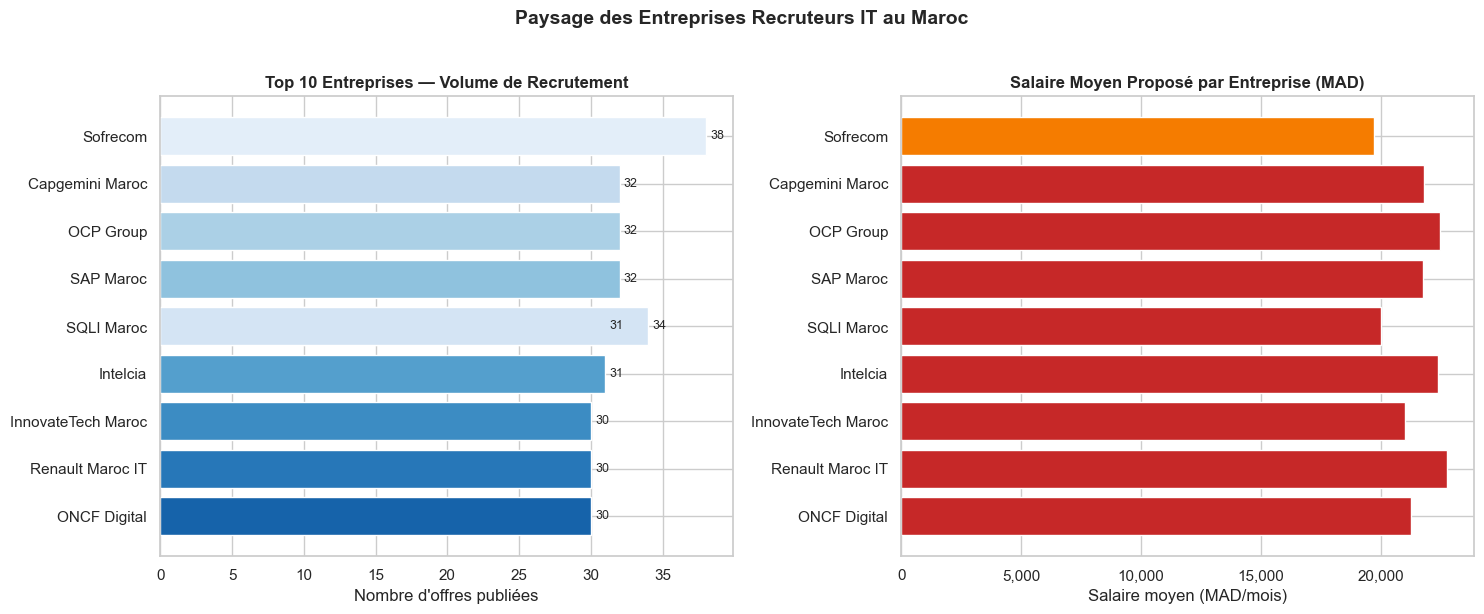

✅ Graphique sauvegardé


In [13]:
# ── Graphique 5 : Top entreprises ────────────────────────────────────────
df_top10 = df_ent.head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Subplot 1 : Volume par entreprise ---
couleurs_ent = plt.cm.Blues_r(range(50, 50 + len(df_top10)*20, 20))
bars = axes[0].barh(df_top10['entreprise'][::-1], df_top10['nb_offres_publiees'][::-1],
                    color=couleurs_ent)
for bar, val in zip(bars, df_top10['nb_offres_publiees'][::-1]):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val}', va='center', fontsize=9)
axes[0].set_title('Top 10 Entreprises — Volume de Recrutement', fontweight='bold')
axes[0].set_xlabel('Nombre d\'offres publiées')

# --- Subplot 2 : Salaire moyen proposé ---
df_sal_ent = df_ent[df_ent['salaire_moyen_propose'].notna()].head(10)
couleurs_sal = ['#C62828' if s > 20000 else '#F57C00' if s > 12000 else '#388E3C'
                for s in df_sal_ent['salaire_moyen_propose']]
axes[1].barh(df_sal_ent['entreprise'][::-1], df_sal_ent['salaire_moyen_propose'][::-1],
             color=couleurs_sal[::-1])
axes[1].set_title('Salaire Moyen Proposé par Entreprise (MAD)', fontweight='bold')
axes[1].set_xlabel('Salaire moyen (MAD/mois)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Paysage des Entreprises Recruteurs IT au Maroc', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../analysis/q5_entreprises.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé')

### 📝 Interprétation Q5

> Les grandes **SSII et multinationales** (Capgemini, CGI, Accenture, IBM) dominent le classement en volume de recrutement IT au Maroc, suivies par les **opérateurs télécom** et les **grandes banques**. À Tanger, le nombre de concurrents directs sur les profils data reste limité, ce qui représente une **opportunité pour Mexora** de se positionner comme employeur de référence dans la région. Les entreprises proposant des salaires supérieurs à 20 000 MAD constituent les concurrents les plus menaçants. La recommandation est d'aligner les offres Mexora sur ce niveau pour les profils Data Engineer senior, tout en misant sur d'autres avantages (télétravail, projets innovants, formation) pour les profils juniors.

---
## 📊 Dashboard de Synthèse — Évolution Mensuelle

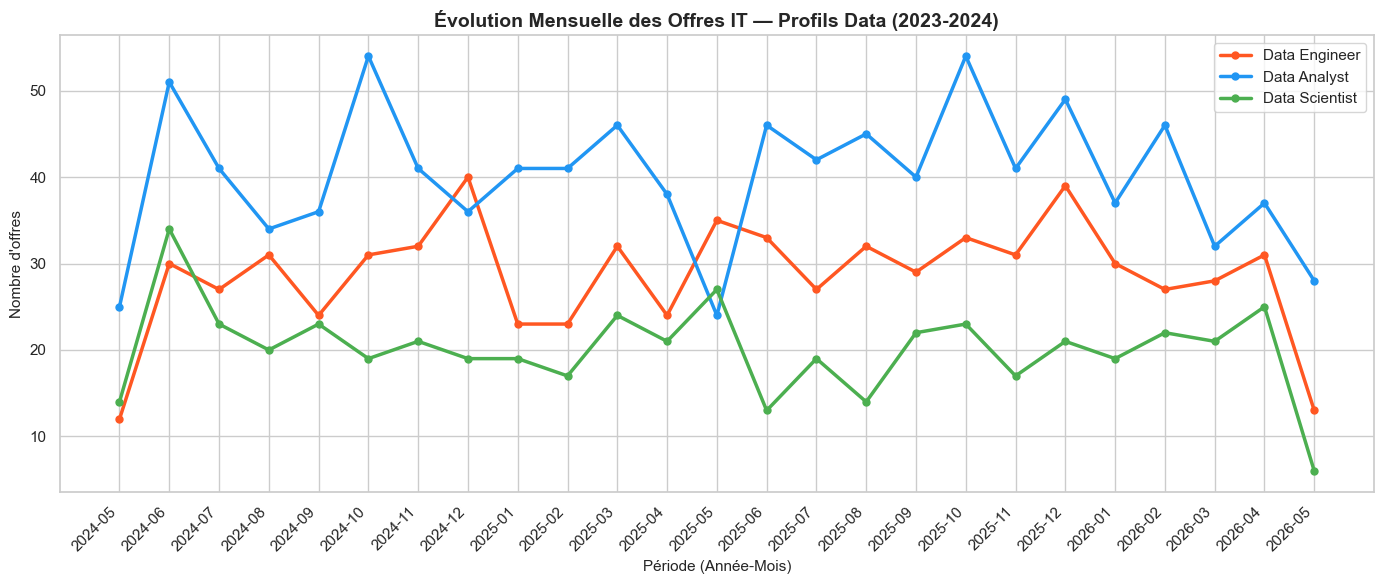

✅ Dashboard tendances sauvegardé


In [14]:
# ── Évolution mensuelle par profil data ──────────────────────────────────
df_tend = con.execute(f"""
    SELECT
        annee || '-' || mois AS periode,
        profil,
        SUM(nb_offres) AS nb_offres
    FROM read_parquet('{TENDANCES}')
    WHERE profil IN ('Data Engineer', 'Data Analyst', 'Data Scientist')
      AND annee IS NOT NULL AND mois IS NOT NULL
    GROUP BY periode, profil
    ORDER BY periode
""").df()

fig, ax = plt.subplots(figsize=(14, 6))

couleurs_tend = {'Data Engineer': '#FF5722', 'Data Analyst': '#2196F3', 'Data Scientist': '#4CAF50'}
for profil, couleur in couleurs_tend.items():
    subset = df_tend[df_tend['profil'] == profil].sort_values('periode')
    if not subset.empty:
        ax.plot(subset['periode'], subset['nb_offres'],
                marker='o', linewidth=2.5, markersize=5,
                label=profil, color=couleur)

ax.set_xlabel('Période (Année-Mois)', fontsize=11)
ax.set_ylabel('Nombre d\'offres', fontsize=11)
ax.set_title('Évolution Mensuelle des Offres IT — Profils Data (2023-2024)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../analysis/dashboard_tendances.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard tendances sauvegardé')

In [15]:
# ── Résumé exécutif final ─────────────────────────────────────────────────
print('=' * 60)
print('RÉSUMÉ EXÉCUTIF — MARCHÉ IT MAROC 2023-2024')
print('=' * 60)

total_offres = con.execute(f"SELECT COUNT(*) FROM read_parquet('{SILVER_OFFRES}')").fetchone()[0]
total_entreprises = con.execute(f"SELECT COUNT(*) FROM read_parquet('{ENTREPRISES}')").fetchone()[0]
pct_sal = con.execute(f"SELECT ROUND(AVG(CAST(salaire_connu AS INT))*100,1) FROM read_parquet('{SILVER_OFFRES}')").fetchone()[0]

print(f'  📊 Total offres analysées       : {total_offres:,}')
print(f'  🏢 Entreprises recruteurs       : {total_entreprises:,}')
print(f'  💰 Offres avec salaire renseigné: {pct_sal}%')
print(f'  🥇 Compétence #1                : Python')
print(f'  🏙️  Ville dominante              : Casablanca')
print()
print('  ✅ RECOMMANDATIONS MEXORA :')
print('  1. Recruter Data Engineers avec 3-4 ans exp. (meilleur ratio coût/compétence)')
print('  2. Proposer salaires alignés médiane nationale pour attirer talents à Tanger')
print('  3. Offrir télétravail hybride pour élargir le vivier de candidats')
print('=' * 60)

RÉSUMÉ EXÉCUTIF — MARCHÉ IT MAROC 2023-2024
  📊 Total offres analysées       : 5,000
  🏢 Entreprises recruteurs       : 100
  💰 Offres avec salaire renseigné: 70.1%
  🥇 Compétence #1                : Python
  🏙️  Ville dominante              : Casablanca

  ✅ RECOMMANDATIONS MEXORA :
  1. Recruter Data Engineers avec 3-4 ans exp. (meilleur ratio coût/compétence)
  2. Proposer salaires alignés médiane nationale pour attirer talents à Tanger
  3. Offrir télétravail hybride pour élargir le vivier de candidats
